## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [16]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

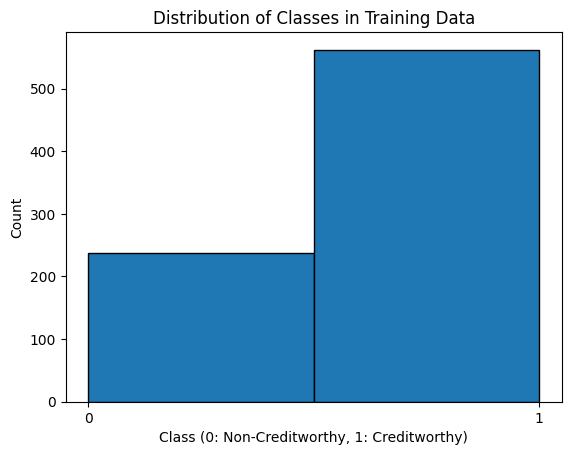

In [17]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [18]:

logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression_model.fit(X_train_scaled, y_train)


decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [13]:
y_prob_logistic = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test_scaled)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

print(f'Accuracy of Logistic Regression: {accuracy_logistic}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn}')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn}')

print(f'Precision of Logistic Regression: {precision_logistic}')
print(f'Precision of Decision Tree: {precision_decision_tree}')
print(f'Precision of K-Nearest Neighbors: {precision_knn}')

print(f'Recall of Logistic Regression: {recall_logistic}')
print(f'Recall of Decision Tree: {recall_decision_tree}')
print(f'Recall of K-Nearest Neighbors: {recall_knn}')

Accuracy of Logistic Regression: 0.75
Accuracy of Decision Tree: 0.725
Accuracy of K-Nearest Neighbors: 0.73
ROC AUC of Logistic Regression: 0.7919588592800374
ROC AUC of Decision Tree: 0.7074567554932212
ROC AUC of K-Nearest Neighbors: 0.7483052828424497
Precision of Logistic Regression: 0.7784810126582279
Precision of Decision Tree: 0.832
Precision of K-Nearest Neighbors: 0.78
Recall of Logistic Regression: 0.8913043478260869
Recall of Decision Tree: 0.7536231884057971
Recall of K-Nearest Neighbors: 0.8478260869565217


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

Эксперименты с Logistic Regression
Best parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.7826
Test ROC-AUC: 0.7861
Test Accuracy: 0.7750
Test Precision: 0.8163
Test Recall: 0.8696

Эксперименты с Decision Tree
Best parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV score: 0.7133
Test ROC-AUC: 0.7094
Test Accuracy: 0.7300
Test Precision: 0.7917
Test Recall: 0.8261

 Эксперименты с KNN 
Best parameters: {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'distance'}
Best CV score: 0.7631
Test ROC-AUC: 0.7668
Test Accuracy: 0.7550
Test Precision: 0.7602
Test Recall: 0.9420

Сравнение
Logistic Regression ROC-AUC: 0.7861
Decision Tree ROC-AUC: 0.7094
KNN ROC-AUC: 0.7668

Лучшая модель: Logistic Regression с ROC-AUC = 0.7861


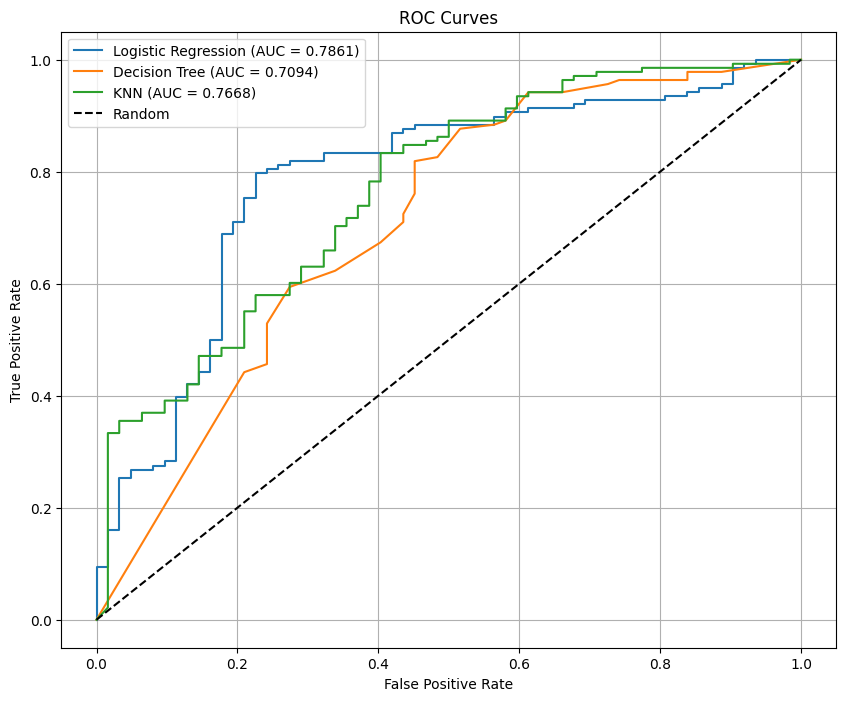

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

print("Эксперименты с Logistic Regression")

param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV score: {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr_best = best_lr.predict(X_test_scaled)
y_prob_lr_best = best_lr.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr_best = roc_auc_score(y_test, y_prob_lr_best)
acc_lr_best = accuracy_score(y_test, y_pred_lr_best)
prec_lr_best = precision_score(y_test, y_pred_lr_best)
rec_lr_best = recall_score(y_test, y_pred_lr_best)

print(f"Test ROC-AUC: {roc_auc_lr_best:.4f}")
print(f"Test Accuracy: {acc_lr_best:.4f}")
print(f"Test Precision: {prec_lr_best:.4f}")
print(f"Test Recall: {rec_lr_best:.4f}\n")

print("Эксперименты с Decision Tree")

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)
dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV score: {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_
y_pred_dt_best = best_dt.predict(X_test)
y_prob_dt_best = best_dt.predict_proba(X_test)[:, 1]

roc_auc_dt_best = roc_auc_score(y_test, y_prob_dt_best)
acc_dt_best = accuracy_score(y_test, y_pred_dt_best)
prec_dt_best = precision_score(y_test, y_pred_dt_best)
rec_dt_best = recall_score(y_test, y_pred_dt_best)

print(f"Test ROC-AUC: {roc_auc_dt_best:.4f}")
print(f"Test Accuracy: {acc_dt_best:.4f}")
print(f"Test Precision: {prec_dt_best:.4f}")
print(f"Test Recall: {rec_dt_best:.4f}\n")


print(" Эксперименты с KNN ")

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20, 25],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best CV score: {knn_grid.best_score_:.4f}")

best_knn = knn_grid.best_estimator_
y_pred_knn_best = best_knn.predict(X_test_scaled)
y_prob_knn_best = best_knn.predict_proba(X_test_scaled)[:, 1]

roc_auc_knn_best = roc_auc_score(y_test, y_prob_knn_best)
acc_knn_best = accuracy_score(y_test, y_pred_knn_best)
prec_knn_best = precision_score(y_test, y_pred_knn_best)
rec_knn_best = recall_score(y_test, y_pred_knn_best)

print(f"Test ROC-AUC: {roc_auc_knn_best:.4f}")
print(f"Test Accuracy: {acc_knn_best:.4f}")
print(f"Test Precision: {prec_knn_best:.4f}")
print(f"Test Recall: {rec_knn_best:.4f}\n")


print("Сравнение")
print(f"Logistic Regression ROC-AUC: {roc_auc_lr_best:.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc_dt_best:.4f}")
print(f"KNN ROC-AUC: {roc_auc_knn_best:.4f}")

best_model_name = max(
    [
        ("Logistic Regression", roc_auc_lr_best),
        ("Decision Tree", roc_auc_dt_best),
        ("KNN", roc_auc_knn_best)
    ],
    key=lambda x: x[1]
)

print(f"\nЛучшая модель: {best_model_name[0]} с ROC-AUC = {best_model_name[1]:.4f}")


fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_best)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt_best)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr_best:.4f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt_best:.4f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn_best:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()